# 01 · Análise Exploratória (EDA) e tratamento de dados

**Datathon MLET · Fase 05 · Experimentação adaptativa com Multi-Armed Bandit**

Base: [Telemarketing JYB Dataset (Víctor Aguado)](https://www.kaggle.com/datasets/aguado/telemarketing-jyb-dataset), derivada da UCI Bank Marketing (Moro, Cortez e Rita, 2014).

## Objetivos deste notebook

1. Carregar a base tratando as particularidades do arquivo (separador `;`, bytes nulos, coluna de índice).
2. Entender as variáveis: perfil do cliente, contexto do contato, histórico de campanha e indicadores macroeconômicos.
3. Documentar decisões de limpeza e o descarte de colunas com vazamento temporal.
4. Analisar o alvo `y` (conversão) e sua relação com as variáveis que o banco **controla** antes de ligar — são elas que vão virar os *braços* do bandit.
5. Salvar a base tratada em `data/processed/` para as etapas seguintes.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Raiz do projeto (o notebook roda dentro de notebooks/, então subimos um nível)
ROOT = Path.cwd().parent
RAW = ROOT / "data" / "raw"
PROCESSED = ROOT / "data" / "processed"

pd.set_option("display.max_columns", 30)
sns.set_theme(style="whitegrid")
print("Raiz:", ROOT)
print("Arquivos brutos:", sorted(p.name for p in RAW.glob("*.csv")))

Raiz: /Users/fabriciodias/Dev/fiap-final
Arquivos brutos: ['test.csv', 'train.csv']


## 1. Carga da base

Três particularidades do arquivo que precisam de tratamento explícito:

- **Separador**: o CSV usa `;` em vez de vírgula. Sem `sep=";"`, o pandas lê tudo como uma coluna só.
- **Primeira linha com bytes nulos**: o cabeçalho vem precedido de centenas de caracteres `\x00`. O pandas os ignora, mas o primeiro nome de coluna fica vazio e vira `Unnamed: 0`.
- **`Unnamed: 0`** é o índice da linha na base UCI original. Não carrega informação sobre o cliente, então é descartado.

O arquivo `test.csv` **não tem a coluna alvo `y`**. Ele não serve para medir desempenho; será usado apenas como conjunto de clientes inéditos na demonstração da Etapa 5. Toda avaliação será feita a partir de `train.csv`.

In [2]:
def load_raw(name: str) -> pd.DataFrame:
    """Lê train.csv ou test.csv tratando separador e coluna de índice."""
    df = pd.read_csv(RAW / f"{name}.csv", sep=";")
    return df.drop(columns=["Unnamed: 0"])

train = load_raw("train")
test = load_raw("test")

print("train:", train.shape)
print("test :", test.shape, "| tem alvo y?", "y" in test.columns)
train.head()

train: (28645, 20)
test : (12543, 19) | tem alvo y? False


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,52,technician,married,high.school,no,yes,no,cellular,nov,tue,1,999,0,nonexistent,-0.1,93.200,-42.0,4.153,5195.8,no
1,33,admin.,single,university.degree,no,yes,no,cellular,nov,thu,1,999,0,nonexistent,-0.1,93.200,-42.0,4.076,5195.8,no
2,54,admin.,single,university.degree,no,yes,no,cellular,may,mon,1,999,0,nonexistent,-1.8,92.893,-46.2,1.264,5099.1,no
3,53,housemaid,married,high.school,no,no,yes,cellular,jun,thu,1,999,2,failure,-2.9,92.963,-40.8,1.260,5076.2,yes
4,42,self-employed,married,university.degree,unknown,yes,no,cellular,aug,tue,2,999,0,nonexistent,1.4,93.444,-36.1,4.966,5228.1,no


## 2. Panorama das variáveis

As 19 features se agrupam em quatro blocos (descrição do autor no Kaggle):

| Bloco | Colunas | O banco controla antes de ligar? |
|---|---|---|
| Perfil do cliente | `age`, `job`, `marital`, `education`, `default`, `housing`, `loan` | Não (é contexto) |
| Contato atual | `contact`, `month`, `day_of_week` | **Sim** (decisão operacional) |
| Histórico de campanha | `campaign`, `pdays`, `previous`, `poutcome` | Parcialmente |
| Macroeconomia | `emp.var.rate`, `cons.price.idx`, `cons.conf.idx`, `euribor3m`, `nr.employed` | Não (é contexto) |

Essa distinção é o coração do projeto: **contexto** é o que o bandit observa, **decisão** é o que ele escolhe.

### Sobre a coluna `duration`

A base UCI original tem `duration` (duração da ligação em segundos). Ela **não está** neste dataset porque o autor já a removeu, e a razão é vazamento temporal: a duração só é conhecida *depois* da ligação, e `duration = 0` implica `y = no`. Um modelo treinado com ela teria desempenho irreal e seria inútil para decidir *antes* de ligar. O enunciado do Datathon cita exatamente este caso.

In [3]:
print("duration presente?", "duration" in train.columns)
print()
train.info()

duration presente? False

<class 'pandas.DataFrame'>
RangeIndex: 28645 entries, 0 to 28644
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             28645 non-null  int64  
 1   job             28645 non-null  str    
 2   marital         28645 non-null  str    
 3   education       28645 non-null  str    
 4   default         28645 non-null  str    
 5   housing         28645 non-null  str    
 6   loan            28645 non-null  str    
 7   contact         28645 non-null  str    
 8   month           28645 non-null  str    
 9   day_of_week     28645 non-null  str    
 10  campaign        28645 non-null  int64  
 11  pdays           28645 non-null  int64  
 12  previous        28645 non-null  int64  
 13  poutcome        28645 non-null  str    
 14  emp.var.rate    28645 non-null  float64
 15  cons.price.idx  28645 non-null  float64
 16  cons.conf.idx   28645 non-null  float64
 17  euribor3m       

In [4]:
# Checagens básicas de qualidade
print("Valores nulos (train):", int(train.isna().sum().sum()))
print("Linhas duplicadas (train):", int(train.duplicated().sum()))
print()
print("Estatísticas das numéricas:")
train.describe().T.round(2)

Valores nulos (train): 0
Linhas duplicadas (train): 890

Estatísticas das numéricas:


,count,mean,std,min,25%,50%,75%,max
age,28645.0,39.98,10.42,17.00,32.00,38.00,47.00,98.00
campaign,28645.0,2.56,2.76,1.00,1.00,2.00,3.00,43.00
pdays,28645.0,962.63,186.53,0.00,999.00,999.00,999.00,999.00
previous,28645.0,0.17,0.49,0.00,0.00,0.00,0.00,7.00
emp.var.rate,28645.0,0.08,1.57,-3.40,-1.80,1.10,1.40,1.40
cons.price.idx,28645.0,93.58,0.58,92.20,93.08,93.80,93.99,94.77
cons.conf.idx,28645.0,-40.48,4.64,-50.80,-42.70,-41.80,-36.40,-26.90
euribor3m,28645.0,3.62,1.74,0.63,1.34,4.86,4.96,5.04
nr.employed,28645.0,5167.00,72.34,4963.60,5099.10,5191.00,5228.10,5228.10


**Leitura das estatísticas:**

- `pdays` tem mediana 999. Esse valor é um código para *"nunca foi contatado em campanha anterior"*, não uma contagem real de dias. Vamos tratar isso na seção de limpeza.
- `campaign` chega a 43 contatos para um mesmo cliente na campanha atual: cauda longa, candidata a *clipping* ou transformação.
- Não há nulos formais, mas várias categóricas têm o valor `unknown`, que funciona como ausente. Veremos a frequência a seguir.

In [5]:
# Valores únicos e frequência de 'unknown' nas categóricas
cat_cols = train.select_dtypes(include="str").columns.tolist()
resumo = pd.DataFrame({
    "n_categorias": [train[c].nunique() for c in cat_cols],
    "pct_unknown": [round(100 * (train[c] == "unknown").mean(), 2) for c in cat_cols],
    "valores": [", ".join(sorted(train[c].unique())) for c in cat_cols],
}, index=cat_cols)
resumo

,n_categorias,pct_unknown,valores
job,12,0.84,"admin., blue-collar, entrepreneur, housemaid, ..."
marital,4,0.20,"divorced, married, single, unknown"
education,8,4.22,"basic.4y, basic.6y, basic.9y, high.school, ill..."
default,3,20.78,"no, unknown, yes"
housing,3,2.46,"no, unknown, yes"
loan,3,2.46,"no, unknown, yes"
contact,2,0.00,"cellular, telephone"
month,10,0.00,"apr, aug, dec, jul, jun, mar, may, nov, oct, sep"
day_of_week,5,0.00,"fri, mon, thu, tue, wed"
poutcome,3,0.00,"failure, nonexistent, success"


## 3. A variável alvo

`y` indica se o cliente assinou o depósito a prazo. É a **recompensa** que o bandit vai aprender a maximizar.

y
no     0.8854
yes    0.1146
Name: proporção, dtype: float64

Taxa de conversão global: 11.46%


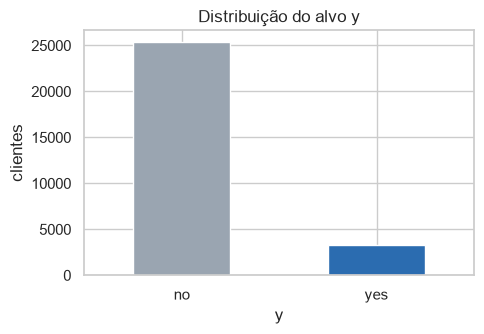

In [6]:
taxa = train["y"].value_counts(normalize=True).rename("proporção")
print(taxa.round(4))
print(f"\nTaxa de conversão global: {100 * (train['y'] == 'yes').mean():.2f}%")

fig, ax = plt.subplots(figsize=(5, 3.5))
train["y"].value_counts().plot.bar(ax=ax, color=["#9aa5b1", "#2b6cb0"])
ax.set_title("Distribuição do alvo y")
ax.set_ylabel("clientes")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()

**Por que isso importa:** apenas ~11,5% convertem. Um modelo que diz sempre "não" acerta 88,5% e é inútil. Por isso, nas próximas etapas, a métrica principal será a **taxa de conversão obtida pela política** (baseline vs. bandit), e não acurácia.


## 4. Conversão por variável de decisão: escolhendo os braços do bandit

Um bandit escolhe entre **ações**. Nesta base há uma única oferta (depósito a prazo), então a ação não é "qual produto", e sim **como abordar**: por qual canal e em que dia ligar. Antes de fixar isso, precisamos verificar se essas variáveis realmente diferenciam a conversão.

Também vamos olhar `month`, que parece uma decisão mas, como veremos, esconde uma armadilha.

,n,taxa
contact,,
cellular,18190,14.97
telephone,10455,5.36


,n,taxa
day_of_week,,
thu,6061,12.19
tue,5608,11.70
wed,5690,11.67
fri,5401,11.37
mon,5885,10.37


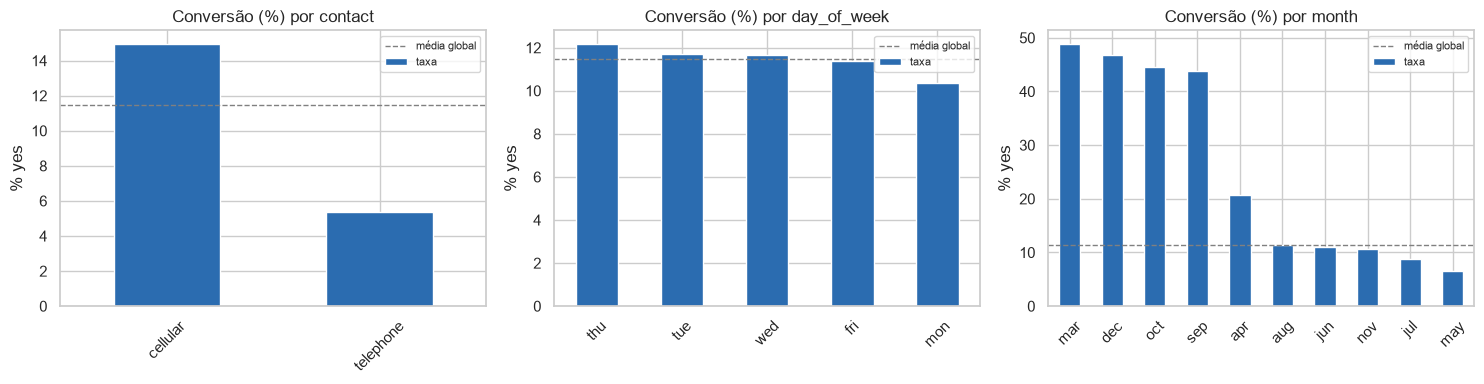

In [7]:
train["conv"] = (train["y"] == "yes").astype(int)

def conversao_por(col: str) -> pd.DataFrame:
    """Volume e taxa de conversão (%) por categoria de `col`."""
    g = train.groupby(col)["conv"].agg(n="size", taxa="mean")
    g["taxa"] = (100 * g["taxa"]).round(2)
    return g.sort_values("taxa", ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["contact", "day_of_week", "month"]):
    g = conversao_por(col)
    g["taxa"].plot.bar(ax=ax, color="#2b6cb0")
    ax.axhline(100 * train["conv"].mean(), color="gray", ls="--", lw=1, label="média global")
    ax.set_title(f"Conversão (%) por {col}")
    ax.set_ylabel("% yes")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=45)
    ax.legend(fontsize=8)
plt.tight_layout()

display(conversao_por("contact"))
display(conversao_por("day_of_week"))

**Leitura:**

- **`contact`**: celular converte quase 3x mais que telefone fixo (≈15% vs ≈5%). Diferença grande e operacionalmente controlável.
- **`day_of_week`**: efeito pequeno (≈10,4% na segunda até ≈12,2% na quinta), mas consistente. É exatamente o tipo de sinal fraco que um bandit explora bem: nenhuma regra fixa vai capturar isso, mas acumulando observações o algoritmo aprende.
- **`month`**: diferenças enormes (março ≈49% vs maio ≈7%). Parece o braço perfeito, mas não é. Veja abaixo.

,n,taxa,euribor3m
month,,,
may,9552,6.61,3.31
jul,5060,8.75,4.69
nov,2845,10.58,3.71
jun,3670,10.93,4.26
aug,4287,11.31,4.27
apr,1822,20.75,1.37
sep,399,43.86,0.83
oct,514,44.55,1.21
dec,124,46.77,0.89


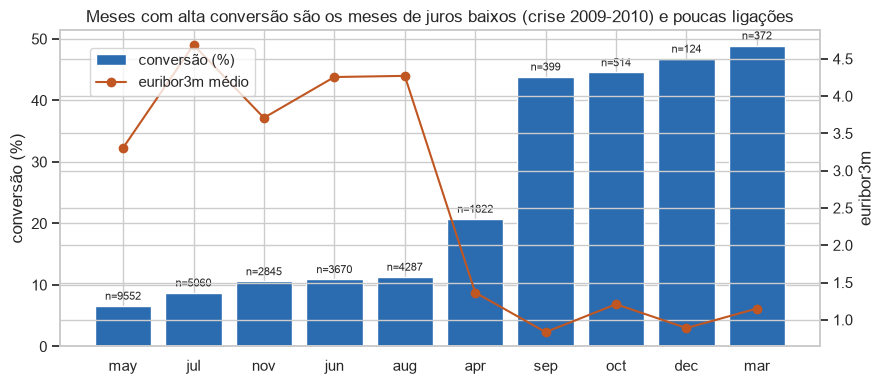

In [8]:
# Por que 'month' NÃO pode ser um braço: ele está colado ao período econômico
m = (train.groupby("month")
          .agg(n=("conv", "size"), taxa=("conv", "mean"), euribor3m=("euribor3m", "mean"))
          .assign(taxa=lambda d: 100 * d["taxa"])
          .sort_values("taxa"))

fig, ax1 = plt.subplots(figsize=(9, 4))
ax1.bar(m.index, m["taxa"], color="#2b6cb0", label="conversão (%)")
ax1.set_ylabel("conversão (%)")
ax2 = ax1.twinx()
ax2.plot(m.index, m["euribor3m"], color="#c05621", marker="o", label="euribor3m médio")
ax2.set_ylabel("euribor3m")
ax1.set_title("Meses com alta conversão são os meses de juros baixos (crise 2009-2010) e poucas ligações")
for i, n in enumerate(m["n"]):
    ax1.text(i, m["taxa"].iloc[i] + 1, f"n={n}", ha="center", fontsize=8)
fig.legend(loc="upper left", bbox_to_anchor=(0.1, 0.88))
plt.tight_layout()
m.round(2)

Os meses de conversão altíssima (mar, sep, oct, dec) têm **poucas centenas de ligações** e coincidem com a fase de juros baixos (euribor < 1,3). Nesse período o banco ligou pouco e para clientes mais qualificados, e o produto (depósito a prazo) ficou mais atraente. Ou seja: o mês não *causa* a conversão; ele *marca o período*. Isso é **confusão (confounding)**: se usássemos `month` como braço, o bandit "aprenderia" que março é mágico, e na prática não dá para escolher ligar em março para todo mundo.

**Decisão:** `month` e os indicadores macroeconômicos entram como **contexto** (o bandit observa), não como ação.

O mesmo cuidado vale, em menor grau, para `contact`: telefone fixo foi mais usado no início da campanha (2008, juros altos). Parte da diferença é época, não canal. Como o bandit contextual receberá `euribor3m` e `emp.var.rate` como contexto, ele consegue separar parcialmente esses efeitos. Registramos isso como limitação.

Volume de ligações por braço:


day_of_week,mon,tue,wed,thu,fri
contact,,,,,
cellular,3821,3521,3549,4078,3221
telephone,2064,2087,2141,1983,2180


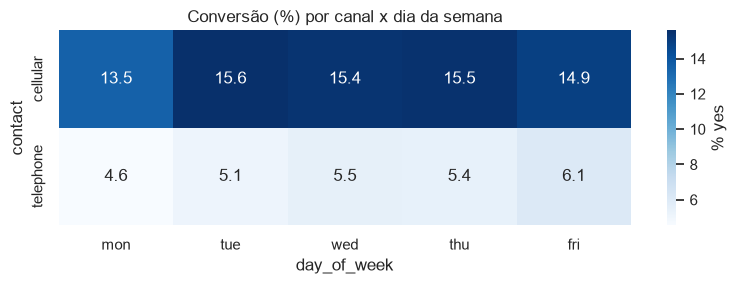

In [9]:
# Cruzamento canal x dia: os 10 braços candidatos
piv = train.pivot_table(index="contact", columns="day_of_week", values="conv", aggfunc="mean") * 100
piv = piv[["mon", "tue", "wed", "thu", "fri"]]
vol = train.pivot_table(index="contact", columns="day_of_week", values="conv", aggfunc="size")[piv.columns]

fig, ax = plt.subplots(figsize=(8, 3))
sns.heatmap(piv, annot=True, fmt=".1f", cmap="Blues", ax=ax, cbar_kws={"label": "% yes"})
ax.set_title("Conversão (%) por canal x dia da semana")
plt.tight_layout()
print("Volume de ligações por braço:")
vol

### Decisão: braços do bandit

| Componente | Definição |
|---|---|
| **Braços (ações)** | 10 combinações de `contact` × `day_of_week` (2 canais × 5 dias) |
| **Contexto** | perfil do cliente (`age`, `job`, `marital`, `education`, `default`, `housing`, `loan`), histórico (`campaign`, `pdays`, `previous`, `poutcome`), período (`month`, indicadores macro) |
| **Recompensa** | `y == "yes"` (1 se converteu, 0 caso contrário) |

Cada braço tem volume razoável (mínimo ≈2.000 ligações), o que garante estimativas estáveis para o baseline e deixa a exploração do bandit visível nos gráficos.

**Baseline natural** para a Etapa 3: o melhor braço histórico global (`cellular` + `tue`, ≈15,6%). O bandit precisa superar isso personalizando por contexto.

### Contexto forte: `poutcome`

Antes de encerrar, vale registrar a variável de contexto mais poderosa da base.

In [10]:
display(conversao_por("poutcome"))
print("pdays == 999 (nunca contatado antes):", f"{100 * (train['pdays'] == 999).mean():.1f}%")

,n,taxa
poutcome,,
success,951,64.46
failure,2870,14.77
nonexistent,24824,9.05


pdays == 999 (nunca contatado antes): 96.3%


Quem já disse "sim" numa campanha anterior (`poutcome = success`) converte ≈64% das vezes, contra ≈9% de quem nunca foi contatado. É um sinal de contexto que o bandit contextual deve capturar, e uma boa fonte para os 5 casos do Golden Set (Etapa 4): esperamos que o modelo trate um cliente com `poutcome = success` de forma diferente de um cliente `nonexistent`.

`pdays = 999` aparece em ≈96% das linhas: é um código, não uma quantidade de dias. Na seção 5 ele vira uma flag `contato_previo`.


## 5. Limpeza, engenharia de atributos e base tratada

Até aqui a função `load_raw` vivia dentro deste notebook. A partir de agora, a carga e a limpeza ficam no pacote `src/datathon/data.py`, e o notebook apenas **importa**. O motivo é engenharia: a API da Etapa 5 vai usar exatamente a mesma função, então o modelo avaliado aqui e o modelo servido lá recebem a mesma transformação. Nada de copiar células.

### Decisões implementadas em `clean()`

| Transformação | Regra | Por quê |
|---|---|---|
| Nomes de colunas | `emp.var.rate` → `emp_var_rate` | Pontos quebram acesso por atributo e JSON da API |
| `pdays = 999` | flag `contato_previo = 0`; valor vira ausente | 999 é código de "nunca contatado", não 999 dias |
| `campaign` | limitado a 14 (percentil 99) | Cauda longa até 43; acima de 10 contatos a conversão é ≈2,9% (594 linhas) |
| `arm` | `contact + "_" + day_of_week` | A ação do bandit, 10 valores |
| `reward` | 1 se `y == "yes"` | A recompensa do bandit |
| Duplicatas | mantidas | Sem id de cliente, cada linha é um contato real |
| `unknown` | mantido como categoria | Não saber é informação (21% em `default`) |

In [11]:
from datathon.data import load_raw, clean, ARM_COLS, CONTEXT_NUM, CONTEXT_CAT

train_clean = clean(load_raw("train"))
test_clean = clean(load_raw("test"))

print("train:", train_clean.shape, "| test:", test_clean.shape)
print("colunas:", list(train_clean.columns))
train_clean.head(3)

train: (28645, 22) | test: (12543, 21)
colunas: ['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'campaign', 'pdays', 'previous', 'poutcome', 'emp_var_rate', 'cons_price_idx', 'cons_conf_idx', 'euribor3m', 'nr_employed', 'contato_previo', 'arm', 'reward']


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,campaign,pdays,previous,poutcome,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,contato_previo,arm,reward
0,52,technician,married,high.school,no,yes,no,cellular,nov,tue,1,NaN,0,nonexistent,-0.1,93.200,-42.0,4.153,5195.8,0,cellular_tue,0
1,33,admin.,single,university.degree,no,yes,no,cellular,nov,thu,1,NaN,0,nonexistent,-0.1,93.200,-42.0,4.076,5195.8,0,cellular_thu,0
2,54,admin.,single,university.degree,no,yes,no,cellular,may,mon,1,NaN,0,nonexistent,-1.8,92.893,-46.2,1.264,5099.1,0,cellular_mon,0


In [12]:
# Verificações das transformações
print("pdays ausente (nunca contatado):", f"{100 * train_clean['pdays'].isna().mean():.1f}%")
print("contato_previo = 1:", f"{100 * train_clean['contato_previo'].mean():.1f}%")
print("campaign máximo após clip:", train_clean["campaign"].max())
print("reward médio:", f"{100 * train_clean['reward'].mean():.2f}%  (deve bater com a taxa de conversão)")
print()
print("Braços e volume:")
train_clean["arm"].value_counts().sort_index()

pdays ausente (nunca contatado): 96.3%
contato_previo = 1: 3.7%
campaign máximo após clip: 14
reward médio: 11.46%  (deve bater com a taxa de conversão)

Braços e volume:


arm
cellular_fri     3221
cellular_mon     3821
cellular_thu     4078
cellular_tue     3521
cellular_wed     3549
telephone_fri    2180
telephone_mon    2064
telephone_thu    1983
telephone_tue    2087
telephone_wed    2141
Name: count, dtype: int64

### Papel de cada coluna daqui em diante

- **Ação** (`ARM_COLS` → `arm`): o que o bandit escolhe.
- **Contexto numérico** (`CONTEXT_NUM`) e **categórico** (`CONTEXT_CAT`): o que o bandit observa.
- **Recompensa** (`reward`): o que o bandit quer maximizar.

Essas listas estão definidas no pacote, então notebook, testes e API concordam sobre quem é quem.

In [13]:
print("Braço formado por:", ARM_COLS)
print("Contexto numérico:", CONTEXT_NUM)
print("Contexto categórico:", CONTEXT_CAT)

Braço formado por: ['contact', 'day_of_week']
Contexto numérico: ['age', 'campaign', 'pdays', 'previous', 'emp_var_rate', 'cons_price_idx', 'cons_conf_idx', 'euribor3m', 'nr_employed', 'contato_previo']
Contexto categórico: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'poutcome', 'month']


### Salvando a base tratada

Parquet em vez de CSV: preserva os tipos (inteiro, float, ausente), é comprimido e lê rápido. A pasta `data/processed/` está no `.gitignore`; qualquer pessoa regenera com este notebook.

In [14]:
PROCESSED.mkdir(parents=True, exist_ok=True)
train_clean.to_parquet(PROCESSED / "train.parquet", index=False)
test_clean.to_parquet(PROCESSED / "test.parquet", index=False)

for p in sorted(PROCESSED.glob("*.parquet")):
    print(f"{p.name}: {p.stat().st_size / 1024:.0f} KB")

test.parquet: 122 KB
train.parquet: 267 KB


## Resumo da EDA (Etapas 1 e 2 concluídas)

1. Base carregada com tratamento de separador e coluna de índice; `test.csv` não tem alvo e serve só para demonstração.
2. `duration` já ausente (vazamento temporal), conforme exigido pelo enunciado.
3. Alvo desbalanceado (11,5% de conversão): a métrica será taxa de conversão da política, não acurácia.
4. Braços definidos como `contact` × `day_of_week` (10); `month` e macroeconomia são contexto, por confusão com o período.
5. Limpeza centralizada em `datathon.data.clean`, coberta por testes, e base tratada salva em Parquet.

**Próximo notebook:** `02_baseline_bandit.ipynb`, com a política fixa (melhor braço histórico) e o Thompson Sampling.